In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
## LOAD DATA FOR SQL
engine = create_engine('sqlite:///data/bird_data.db')
df = pd.read_sql("SELECT * FROM bird_observations", con=engine)

print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print(df.head())

Total rows: 17077
Total columns: 33
  Admin_Unit_Code Sub_Unit_Code Site_Name  Plot_Name Location_Type  Year  \
0            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
1            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
2            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
3            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   
4            ANTI           NaN    ANTI 1  ANTI-0036        Forest  2018   

                         Date       Start_Time         End_Time  \
0  2018-05-22 00:00:00.000000  06:19:00.000000  06:29:00.000000   
1  2018-05-22 00:00:00.000000  06:19:00.000000  06:29:00.000000   
2  2018-05-22 00:00:00.000000  06:19:00.000000  06:29:00.000000   
3  2018-05-22 00:00:00.000000  06:19:00.000000  06:29:00.000000   
4  2018-05-22 00:00:00.000000  06:19:00.000000  06:29:00.000000   

           Observer  ...  Temperature   Humidity              Sky  \
0  Elizabeth Oswald  ...         19

In [3]:
### BASIC OVERVIEW

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nLocation Types:\n", df['Location_Type'].value_counts())

Shape: (17077, 33)

Column Names:
 ['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name', 'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer', 'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed', 'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode', 'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status', 'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance', 'Initial_Three_Min_Cnt', 'Previously_Obs', 'TaxonCode', 'Month', 'Season']

Missing Values:
 Admin_Unit_Code                    0
Sub_Unit_Code                  16355
Site_Name                          0
Plot_Name                          0
Location_Type                      0
Year                               0
Date                               0
Start_Time                         0
End_Time                           0
Observer                           0
Visit                              0
Interval_Length                    0
ID_Method                

In [4]:
### UNIQUE SPECIES COUNT

print("Total Unique Species:", df['Scientific_Name'].nunique())
print("\nTop 10 Most Observed Species:")
print(df['Common_Name'].value_counts().head(10))

Total Unique Species: 127

Top 10 Most Observed Species:
Common_Name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              739
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64


Species per Habitat:
 Location_Type
Forest       108
Grassland    107
Name: Scientific_Name, dtype: int64


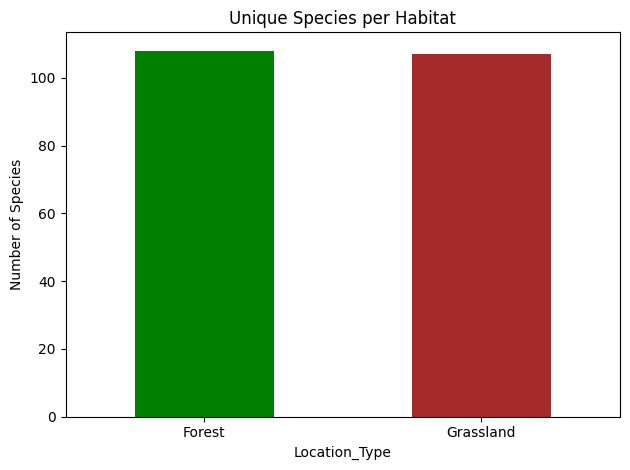

In [5]:
### SPECIES PER HABITAT

habitat_species = df.groupby('Location_Type')['Scientific_Name'].nunique()
print("Species per Habitat:\n", habitat_species)

# Bar chart
habitat_species.plot(kind='bar', color=['green', 'brown'], 
                     title='Unique Species per Habitat')
plt.ylabel('Number of Species')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Location_Type  Forest  Grassland
Year                            
2018             8546       8531


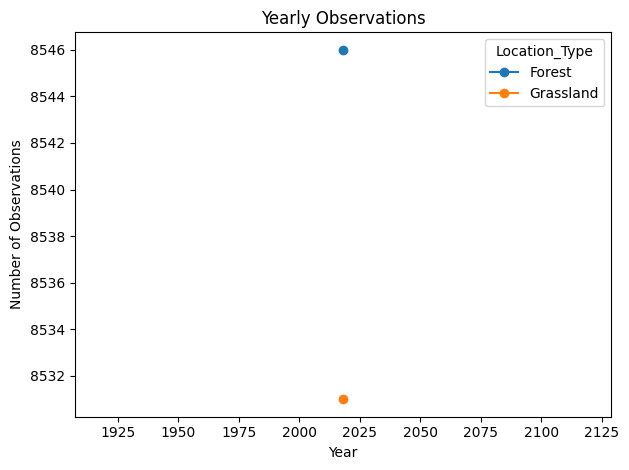

In [6]:
### OBSERVATION PER YEAR

yearly = df.groupby(['Year', 'Location_Type']).size().unstack()
print(yearly)

yearly.plot(kind='line', marker='o', title='Yearly Observations')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

Location_Type  Forest  Grassland
Season                          
Spring         2390.0     3206.0
Summer         6156.0     5325.0
Autumn            NaN        NaN
Winter            NaN        NaN


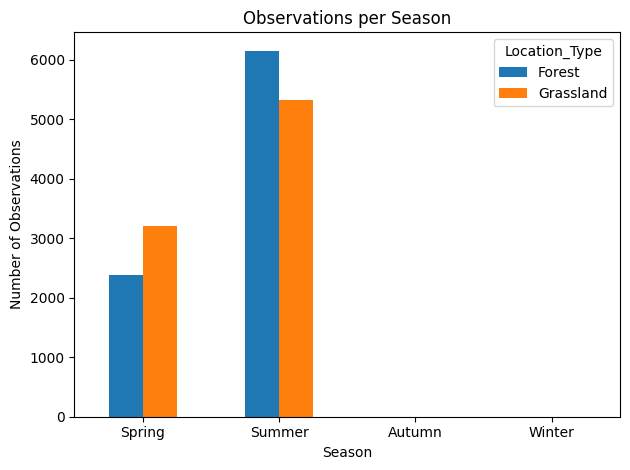

In [7]:
### SEASONAL ANALYSIS

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal = df.groupby(['Season', 'Location_Type']).size().unstack()
seasonal = seasonal.reindex(season_order)
print(seasonal)

seasonal.plot(kind='bar', title='Observations per Season')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
### CONSERVATION / WATCHLIST SPECIES

watchlist = df[df['PIF_Watchlist_Status'] == True]
print("At-risk species count:", len(watchlist))
print("\nAt-risk species:\n", 
      watchlist['Common_Name'].value_counts().head(10))

At-risk species count: 378

At-risk species:
 Common_Name
Wood Thrush              309
Worm-eating Warbler       31
Prairie Warbler           25
Cerulean Warbler           7
Kentucky Warbler           2
Willow Flycatcher          2
Blue-winged Warbler        1
Red-headed Woodpecker      1
Name: count, dtype: int64


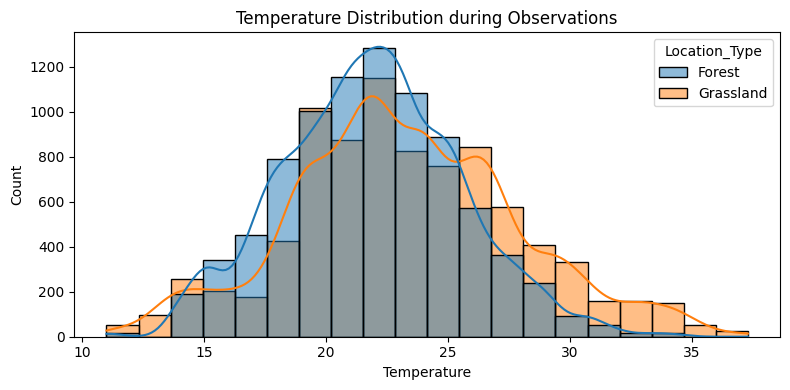

In [9]:
### TEMPERATURE VS OBSERVATION

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Temperature', hue='Location_Type', 
             bins=20, kde=True)
plt.title('Temperature Distribution during Observations')
plt.tight_layout()
plt.show()

ID_Method
Singing          9863
Calling          4061
Visualization    3151
Name: count, dtype: int64


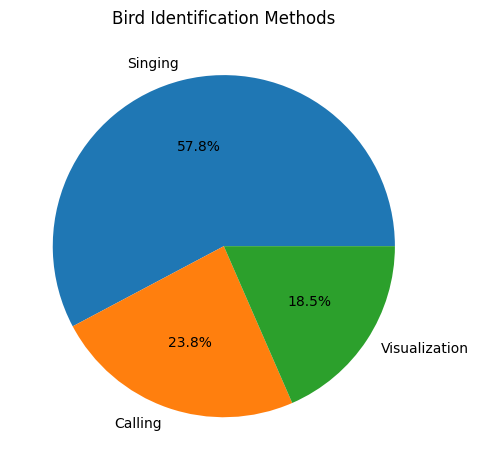

In [10]:
### IDENTIFICATION METHOD

id_method = df['ID_Method'].value_counts()
print(id_method)

id_method.plot(kind='pie', autopct='%1.1f%%', 
               title='Bird Identification Methods')
plt.ylabel('')
plt.tight_layout()
plt.show()